<a href="https://colab.research.google.com/github/TathanBello/1/blob/main/Transformacion_de_texto_en_embeddings_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformación de texto en embeddings utilizando TensorFlow

**Nombre:** Jonathan David Lancheros Bello  
**Asignatura:** Procesamiento de lenguaje natural  
**Actividad:** Transformación de texto en embeddings  

## Introducción

En este laboratorio se realiza un ejercicio práctico para comprender cómo un texto puede ser transformado en una representación numérica utilizando TensorFlow.

Primero se trabaja con un conjunto pequeño de textos, después se realiza la conversión de las palabras a números y finalmente se utiliza una capa de embeddings para obtener vectores numéricos.

El objetivo es observar de manera práctica cómo se puede preparar información textual para utilizarla en modelos de aprendizaje automático.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("Versión de TensorFlow:", tf.__version__)

Versión de TensorFlow: 2.20.0


In [ ]:
textos = [
    "Python es un lenguaje de programación muy utilizado.",
    "TensorFlow permite desarrollar modelos de aprendizaje automático.",
    "Los embeddings representan palabras mediante vectores numéricos.",
    "El aprendizaje automático permite analizar grandes cantidades de datos.",
    "Las redes neuronales pueden utilizar representaciones numéricas del texto."
]

for i, texto in enumerate(textos):
    print(f"{i + 1}. {texto}")

1. Python es un lenguaje de programación muy utilizado.
2. TensorFlow permite desarrollar modelos de aprendizaje automático.
3. Los embeddings representan palabras mediante vectores numéricos.
4. El aprendizaje automático permite analizar grandes cantidades de datos.
5. Las redes neuronales pueden utilizar representaciones numéricas del texto.


In [ ]:
vectorizador = tf.keras.layers.TextVectorization(
    max_tokens=100,
    output_mode="int",
    output_sequence_length=10
)

vectorizador.adapt(textos)

In [ ]:
vocabulario = vectorizador.get_vocabulary()

print("Cantidad de palabras en el vocabulario:", len(vocabulario))
print("\nVocabulario:")

for i, palabra in enumerate(vocabulario):
    print(i, "->", palabra)

Cantidad de palabras en el vocabulario: 37

Vocabulario:
0 -> 
1 -> [UNK]
2 -> de
3 -> permite
4 -> automático
5 -> aprendizaje
6 -> vectores
7 -> utilizar
8 -> utilizado
9 -> un
10 -> texto
11 -> tensorflow
12 -> representan
13 -> representaciones
14 -> redes
15 -> python
16 -> pueden
17 -> programación
18 -> palabras
19 -> numéricos
20 -> numéricas
21 -> neuronales
22 -> muy
23 -> modelos
24 -> mediante
25 -> los
26 -> lenguaje
27 -> las
28 -> grandes
29 -> es
30 -> embeddings
31 -> el
32 -> desarrollar
33 -> del
34 -> datos
35 -> cantidades
36 -> analizar


In [ ]:
textos_numericos = vectorizador(tf.constant(textos))

print("Representación numérica de los textos:\n")
print(textos_numericos.numpy())

Representación numérica de los textos:

[[15 29  9 26  2 17 22  8  0  0]
 [11  3 32 23  2  5  4  0  0  0]
 [25 30 12 18 24  6 19  0  0  0]
 [31  5  4  3 36 28 35  2 34  0]
 [27 14 21 16  7 13 20 33 10  0]]


In [ ]:
tamano_vocabulario = len(vocabulario)
dimension_embedding = 8

embedding = tf.keras.layers.Embedding(
    input_dim=tamano_vocabulario,
    output_dim=dimension_embedding
)

print("Tamaño del vocabulario:", tamano_vocabulario)
print("Dimensión del embedding:", dimension_embedding)

Tamaño del vocabulario: 37
Dimensión del embedding: 8


In [ ]:
vectores = embedding(textos_numericos)

print("Forma de los embeddings:")
print(vectores.shape)

Forma de los embeddings:
(5, 10, 8)


In [ ]:
print("Embedding del primer texto:")
print(vectores[0].numpy())

Embedding del primer texto:
[[ 0.00367409 -0.00574387  0.02417422 -0.02020173 -0.00396804 -0.02377647
   0.0329165  -0.04174192]
 [-0.02372224 -0.04610252  0.04327886 -0.01859318  0.03762505 -0.02028229
   0.01307224 -0.02594848]
 [ 0.03181211 -0.04105728 -0.04011976 -0.00562376 -0.00461793  0.03325779
   0.03659227 -0.00796481]
 [ 0.02859714  0.0043908  -0.0480057   0.0336607   0.02175963 -0.04405097
  -0.04658166 -0.04973557]
 [-0.02710348  0.01754499  0.02386621  0.03302056 -0.03956919  0.03211722
   0.00296197 -0.04062451]
 [ 0.01228863  0.03682882 -0.00562025  0.01652987 -0.0189526  -0.00137346
   0.04002075 -0.03749061]
 [ 0.04635498 -0.00936126  0.01935964 -0.01659228  0.00940941  0.04800628
  -0.01109881  0.02080956]
 [ 0.00935831  0.02491881 -0.04895811 -0.0392571  -0.02372937 -0.00810713
  -0.03396919 -0.04617306]
 [ 0.04096321  0.0038378   0.00470535 -0.03442477 -0.02431799  0.0436711
   0.02956975 -0.03599516]
 [ 0.04096321  0.0038378   0.00470535 -0.03442477 -0.02431799  0

In [ ]:
# Guardamos los embeddings generados para poder analizarlos
embeddings = embedding(textos_numericos)

print("Forma de los embeddings:")
print(embeddings.shape)

Forma de los embeddings:
(5, 10, 8)


In [ ]:
print("Embedding del primer texto:")
print(embeddings[0])

Embedding del primer texto:
tf.Tensor(
[[ 0.00367409 -0.00574387  0.02417422 -0.02020173 -0.00396804 -0.02377647
   0.0329165  -0.04174192]
 [-0.02372224 -0.04610252  0.04327886 -0.01859318  0.03762505 -0.02028229
   0.01307224 -0.02594848]
 [ 0.03181211 -0.04105728 -0.04011976 -0.00562376 -0.00461793  0.03325779
   0.03659227 -0.00796481]
 [ 0.02859714  0.0043908  -0.0480057   0.0336607   0.02175963 -0.04405097
  -0.04658166 -0.04973557]
 [-0.02710348  0.01754499  0.02386621  0.03302056 -0.03956919  0.03211722
   0.00296197 -0.04062451]
 [ 0.01228863  0.03682882 -0.00562025  0.01652987 -0.0189526  -0.00137346
   0.04002075 -0.03749061]
 [ 0.04635498 -0.00936126  0.01935964 -0.01659228  0.00940941  0.04800628
  -0.01109881  0.02080956]
 [ 0.00935831  0.02491881 -0.04895811 -0.0392571  -0.02372937 -0.00810713
  -0.03396919 -0.04617306]
 [ 0.04096321  0.0038378   0.00470535 -0.03442477 -0.02431799  0.0436711
   0.02956975 -0.03599516]
 [ 0.04096321  0.0038378   0.00470535 -0.03442477 -0.

In [ ]:
# Calculamos el promedio de los vectores de cada texto
embeddings_promedio = tf.reduce_mean(embeddings, axis=1)

print("Embeddings promedio de cada texto:")
print(embeddings_promedio.numpy())

Embeddings promedio de cada texto:
[[ 0.01631859 -0.00109059 -0.00226142 -0.00859065 -0.0070679   0.01031332
   0.00930536 -0.03008597]
 [ 0.01328366 -0.00387653  0.0007777  -0.01353271 -0.02730848  0.00514289
   0.00727674 -0.01746004]
 [ 0.01998443 -0.00088916 -0.02000766 -0.01183148 -0.01107603  0.01164148
   0.00704098 -0.00666669]
 [ 0.00206479 -0.00173975  0.0004499  -0.00288012 -0.01037355  0.00765145
  -0.00034865 -0.00525242]
 [ 0.01343302 -0.0051786  -0.00178613  0.00143143 -0.00675186  0.01528099
   0.00526036  0.00546377]]


In [ ]:
print("Forma de los embeddings promedio:")
print(embeddings_promedio.shape)

Forma de los embeddings promedio:
(5, 8)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculamos la similitud entre los textos
similitudes = cosine_similarity(embeddings_promedio.numpy())

print("Matriz de similitud:")
print(np.round(similitudes, 2))

Matriz de similitud:
[[1.   0.78 0.68 0.65 0.34]
 [0.78 1.   0.68 0.86 0.42]
 [0.68 0.68 1.   0.58 0.65]
 [0.65 0.86 0.58 1.   0.55]
 [0.34 0.42 0.65 0.55 1.  ]]


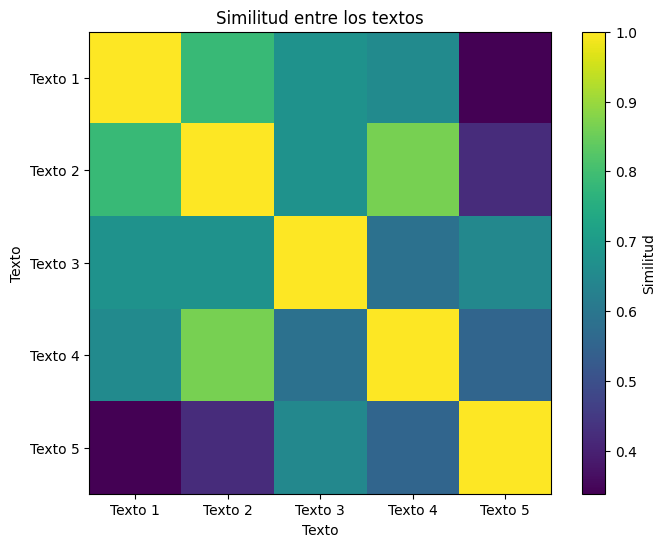

In [ ]:
plt.figure(figsize=(8, 6))

plt.imshow(similitudes)

plt.colorbar(label="Similitud")

plt.title("Similitud entre los textos")
plt.xlabel("Texto")
plt.ylabel("Texto")

plt.xticks(range(len(textos)), [f"Texto {i+1}" for i in range(len(textos))])
plt.yticks(range(len(textos)), [f"Texto {i+1}" for i in range(len(textos))])

plt.show()

In [ ]:
# Buscamos los textos con mayor similitud sin contar la diagonal
similitudes_sin_diagonal = similitudes.copy()
np.fill_diagonal(similitudes_sin_diagonal, -1)

indice_maximo = np.unravel_index(
    np.argmax(similitudes_sin_diagonal),
    similitudes_sin_diagonal.shape
)

texto_1 = indice_maximo[0] + 1
texto_2 = indice_maximo[1] + 1
valor = similitudes_sin_diagonal[indice_maximo]

print(f"Los textos con mayor similitud son el Texto {texto_1} y el Texto {texto_2}.")
print(f"Valor de similitud: {valor:.2f}")

Los textos con mayor similitud son el Texto 2 y el Texto 4.
Valor de similitud: 0.86
